# ============================================================
# Iris Dataset Exploration and Visualization
# Internship Task: Understanding how to read, summarize,
# and visualize a dataset using pandas, matplotlib & seaborn
# ============================================================

In [4]:
# --- Import Required Libraries ---
import pandas as pd          # For loading and manipulating data
import matplotlib.pyplot as plt  # For creating plots and figures
import seaborn as sns        # For beautiful statistical visualizations
import warnings             # To handle any warnings that may arise
warnings.filterwarnings('ignore')  # Ignore warnings for cleaner output


# Load the Iris dataset directly from seaborn's built-in datasets
# This returns it as a pandas DataFrame (like a spreadsheet in Python)
df = sns.load_dataset('iris')


In [5]:
# .shape returns a tuple (rows, columns) — tells us the size of the dataset
print("Dataset Shape (rows, columns):")
print(df.shape)
print()

# .columns returns the list of all column names in the dataset
print("Column Names:")
print(df.columns.tolist())
print()

# .head() displays the first 5 rows by default — gives a quick preview
print("First 5 Rows of the Dataset:")
print(df.head())
print()

# .dtypes shows the data type of each column (int, float, object, etc.)
print("Data Types of Each Column:")
print(df.dtypes)
print()

# .describe() gives statistical summary: count, mean, std, min, max, etc.
print("Statistical Summary:")
print(df.describe())
print()

# Check for any missing/null values in the dataset
print("Missing Values per Column:")
print(df.isnull().sum())
print()


Dataset Shape (rows, columns):
(150, 5)

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 Rows of the Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Data Types of Each Column:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Statistical Summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000 

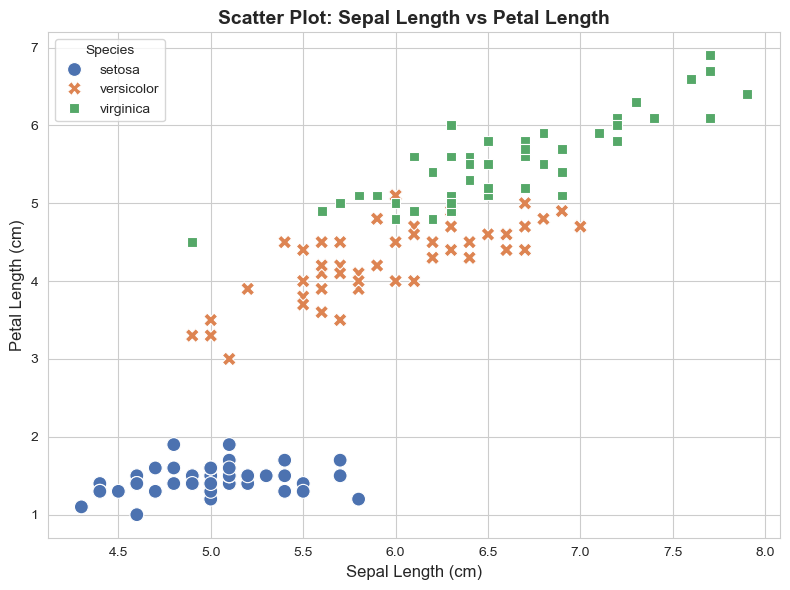

In [6]:
# Set the overall style for all seaborn plots
# 'whitegrid' gives a clean white background with gridlines
sns.set_style("whitegrid")

# Set a color palette — 'deep' gives distinct colors per species
sns.set_palette("deep")

# ---- FIGURE 1: Scatter Plot ----
# Goal: Analyze the relationship between sepal length and petal length
# Each dot represents one flower, colored by species

plt.figure(figsize=(8, 6))  # Set figure size (width=8 inches, height=6 inches)

# scatterplot() plots each row as a point
# hue='species' colors points differently based on the species column
# style='species' changes the marker shape per species (circle, square, etc.)
sns.scatterplot(
    data=df,             # The DataFrame to use
    x='sepal_length',    # Column for the X-axis
    y='petal_length',    # Column for the Y-axis
    hue='species',       # Color each species differently
    style='species',     # Different marker shapes per species
    s=100                # Size of each dot
)

# Add a descriptive title and axis labels
plt.title('Scatter Plot: Sepal Length vs Petal Length', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)   # Label for X-axis
plt.ylabel('Petal Length (cm)', fontsize=12)   # Label for Y-axis
plt.legend(title='Species', fontsize=10)        # Show legend with species names

plt.tight_layout()           # Automatically adjust spacing so nothing is cut off
plt.savefig('scatter_plot.png', dpi=150)  # Save the plot as a PNG image
plt.show() 

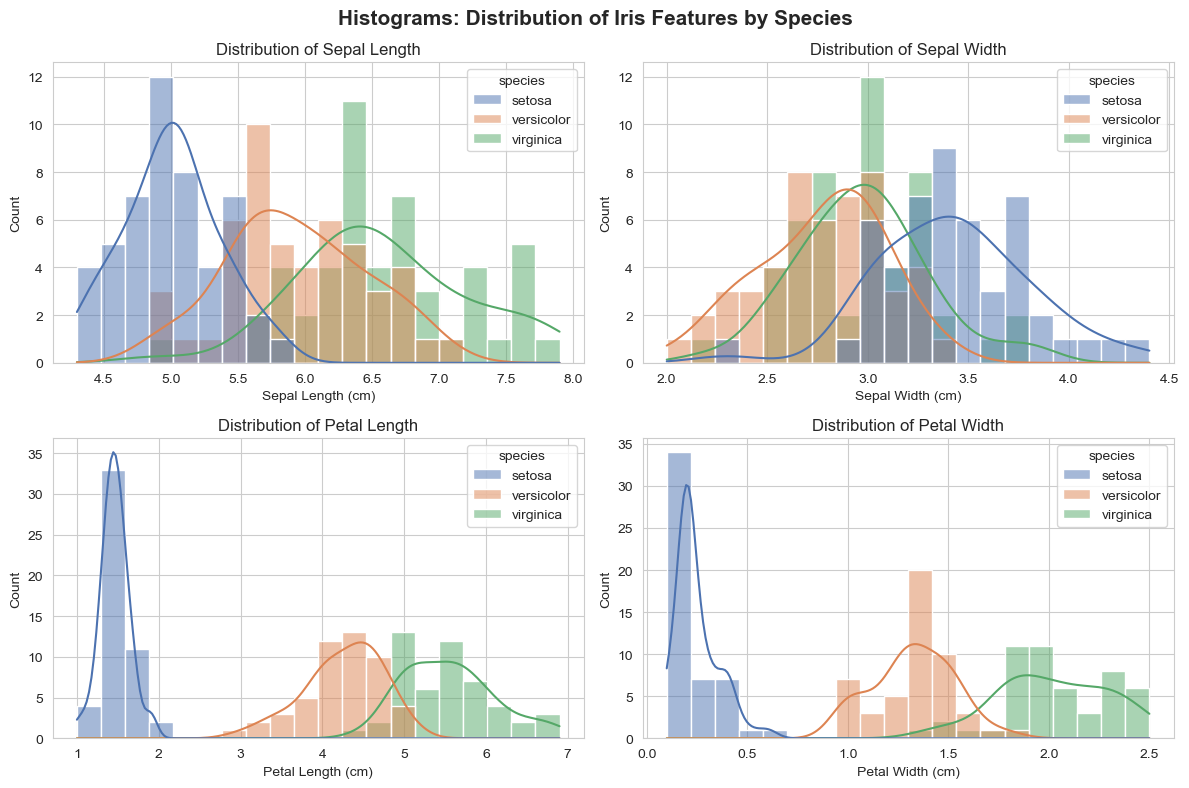

In [7]:
# ---- FIGURE 2: Histogram ----
# Goal: Examine the distribution (spread and frequency) of each numeric feature

# Create a figure with 4 subplots arranged in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows, 2 columns of plots

# List of the 4 numeric columns we want to plot histograms for
numeric_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Loop through each column and plot its histogram in the corresponding subplot
for i, col in enumerate(numeric_columns):
    row = i // 2    # Determine which row (0 or 1) this subplot goes in
    col_idx = i % 2  # Determine which column (0 or 1) this subplot goes in

    # histplot() creates a histogram with an optional KDE (density curve) overlay
    # kde=True adds a smooth curve showing the overall distribution shape
    sns.histplot(
        data=df,         # The DataFrame
        x=col,           # Column to plot
        hue='species',   # Color-code bars by species
        kde=True,        # Add a Kernel Density Estimate (smooth curve)
        ax=axes[row, col_idx],   # Which subplot to draw on
        bins=20          # Number of bins (bars) in the histogram
    )

    # Set a title for each individual subplot
    axes[row, col_idx].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12)
    axes[row, col_idx].set_xlabel(col.replace("_", " ").title() + " (cm)", fontsize=10)
    axes[row, col_idx].set_ylabel("Count", fontsize=10)

# Set an overall title for the entire figure
fig.suptitle('Histograms: Distribution of Iris Features by Species', fontsize=15, fontweight='bold')
plt.tight_layout()                       # Adjust layout so subplots don't overlap
plt.savefig('histogram.png', dpi=150)   # Save the figure as PNG
plt.show()                               # Display it

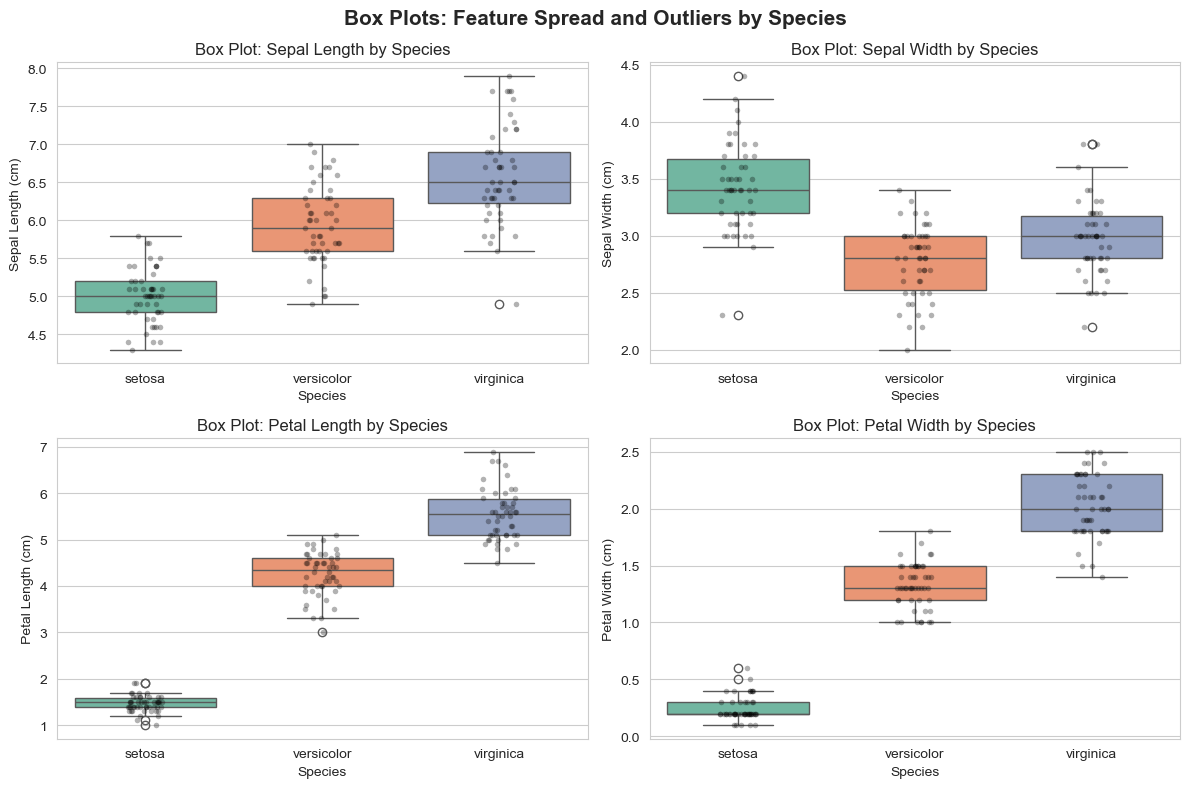

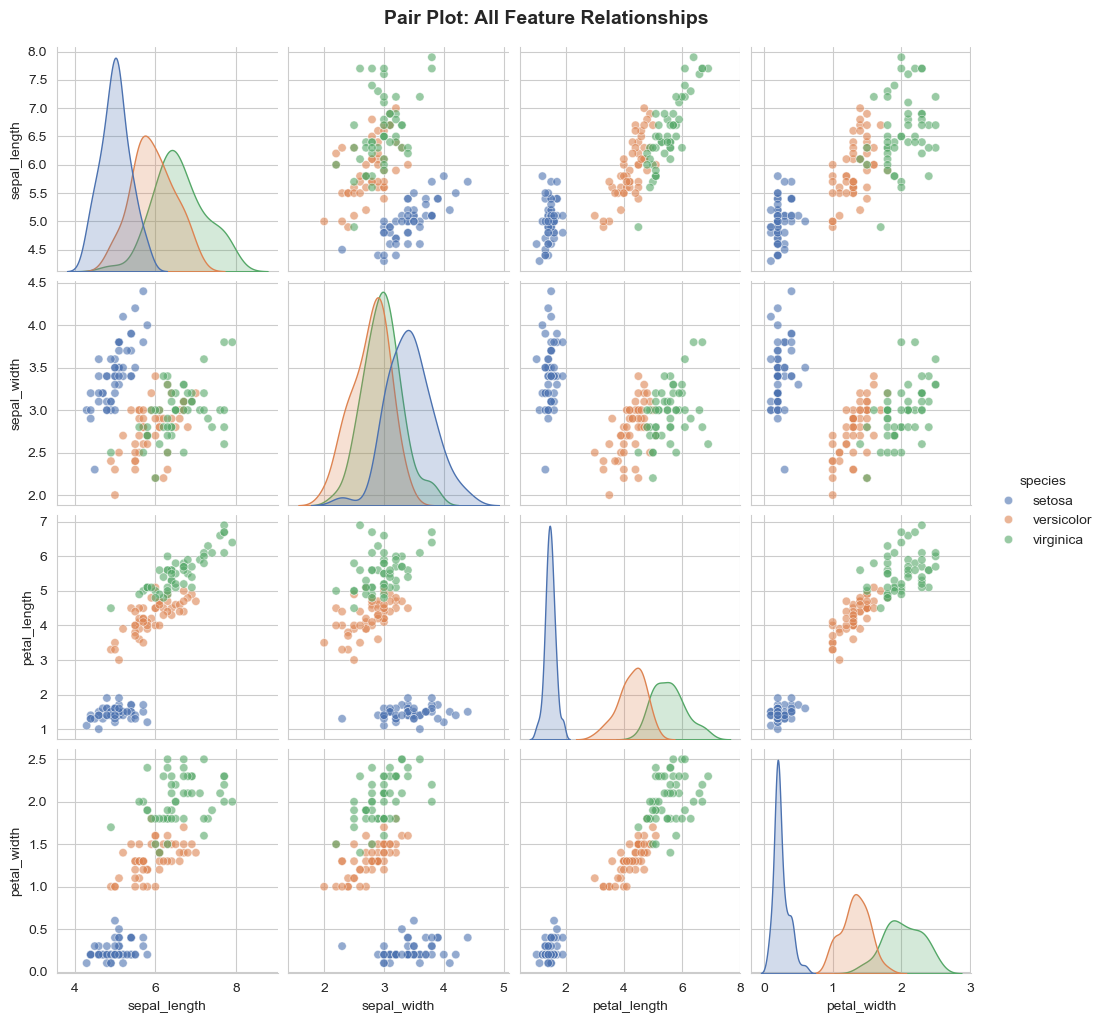

All visualizations have been created and saved successfully!
Files saved: scatter_plot.png, histogram.png, boxplot.png, pairplot.png


In [9]:


# ---- FIGURE 3: Box Plot ----
# Goal: Detect outliers and compare the spread/range of values per species
# A box plot shows: median, quartiles (Q1, Q3), and outliers (dots outside whiskers)

# Create a figure with 4 subplots, one for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop through each numeric column again for the box plots
for i, col in enumerate(numeric_columns):
    row = i // 2      # Row index for this subplot
    col_idx = i % 2   # Column index for this subplot

    # boxplot() draws a box-and-whisker plot
    # x='species' groups data by species on the X-axis
    # y=col puts the feature values on the Y-axis
    sns.boxplot(
        data=df,           # The DataFrame
        x='species',       # Group by species on X-axis
        y=col,             # Feature values on Y-axis
        ax=axes[row, col_idx],  # Target subplot
        palette='Set2'     # Color palette for the boxes
    )

    # Optional: Overlay actual data points using stripplot for better visibility
    sns.stripplot(
        data=df,
        x='species',
        y=col,
        ax=axes[row, col_idx],
        color='black',   # Black dots for contrast
        alpha=0.3,       # 30% transparency so they don't clutter
        size=4           # Small dot size
    )

    # Title and axis labels for each subplot
    axes[row, col_idx].set_title(f'Box Plot: {col.replace("_", " ").title()} by Species', fontsize=12)
    axes[row, col_idx].set_xlabel('Species', fontsize=10)
    axes[row, col_idx].set_ylabel(col.replace("_", " ").title() + " (cm)", fontsize=10)

# Overall title for the box plot figure
fig.suptitle('Box Plots: Feature Spread and Outliers by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)   # Save the box plots as PNG
plt.show()



# pairplot() creates a grid of scatter plots for every combination of features
# diag_kind='kde' puts a density curve on the diagonal (where a feature meets itself)
pair_plot = sns.pairplot(
    df,                  # The full DataFrame
    hue='species',       # Color by species
    diag_kind='kde',     # KDE curve on diagonal subplots
    plot_kws={'alpha': 0.6}  # Slight transparency for overlapping points
)

pair_plot.fig.suptitle('Pair Plot: All Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=150)
plt.show()


print("All visualizations have been created and saved successfully!")
print("Files saved: scatter_plot.png, histogram.png, boxplot.png, pairplot.png")